# Lazada Uplift — Hyperparameter Tuning & MLflow

Notebook thứ ba. Nhận 4 tập parquet từ `02_feature_engineering.ipynb`, làm ba việc:

1. Tính **DR-score** trên tập Val để làm thước đo tinh chỉnh
2. Tinh chỉnh siêu tham số cho **6 mô hình** bằng Optuna
3. Ghi vết toàn bộ thí nghiệm lên **MLflow**

### Vì sao phải tách riêng notebook này

Tinh chỉnh chạy rất lâu. Tách riêng để chạy một lần rồi thôi — notebook 04 chỉ cần đọc file tham số tốt nhất, không phải chạy lại mỗi khi sửa biểu đồ.

### Vấn đề cần giải: chấm điểm trên dữ liệu có thiên vị

Tập Val cắt ra từ dữ liệu quan sát nên **không đo Qini được** — thứ hạng bị bóp méo bởi việc ai được phát voucher. Mà cũng không có CATE thật để so.

Lời giải là **DR-score**: dùng chính pseudo-outcome doubly robust làm nhãn thay thế cho CATE thật.

$$\tilde{Y}_i = \hat\mu_1(X_i) - \hat\mu_0(X_i) + \frac{W_i\,(Y_i - \hat\mu_1)}{\hat e_i} - \frac{(1-W_i)(Y_i - \hat\mu_0)}{1 - \hat e_i}$$

Điểm mấu chốt: $\tilde{Y}_i$ có **kỳ vọng đúng bằng CATE thật** kể cả trên dữ liệu có thiên vị, miễn là một trong hai mô hình phụ ước lượng đúng. Nên nó là nhãn thay thế hợp lệ, dù từng giá trị riêng lẻ rất nhiễu.

Thước đo tinh chỉnh:

$$\text{DR-MSE} = \frac{1}{n}\sum_i \left(\hat\tau(X_i) - \tilde{Y}_i\right)^2 \quad \text{— càng thấp càng tốt}$$

### Đầu ra

`mlflow.db` và `artifacts/best_params.json`

---
# Phần 1 — Thiết lập

### Bước 1 — Import thư viện

In [1]:
import os
if os.path.exists('/kaggle'):
    get_ipython().run_line_magic('pip', 'install -q econml optuna mlflow')
else:
    print('Local: dependencies are managed by uv (uv sync --frozen).')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7

In [2]:
import os
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb

import optuna
import mlflow
from econml.dml import LinearDML, NonParamDML, CausalForestDML

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    print("📌 Đang chạy trên Kaggle Environment")
    # Đường dẫn chính xác từ kết quả kiểm tra
    DATA_DIR = '/kaggle/input/datasets/hatrungkienhatuki/lazada-uplift-data'
    ART_DIR = '/kaggle/working/artifacts'
    FIG_DIR = '/kaggle/working/reports/figures'
else:
    print("📌 Đang chạy trên máy Local")
    ROOT = '..' if os.path.basename(os.getcwd()) == 'notebooks' else '.'
    DATA_DIR = os.path.join(ROOT, 'dataset')
    ART_DIR = os.path.join(ROOT, 'artifacts')
    FIG_DIR = os.path.join(ROOT, 'reports', 'figures')

os.makedirs(ART_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print(f"DATA_DIR: {DATA_DIR}")
print(f"ART_DIR : {ART_DIR}")
print('optuna', optuna.__version__, '| mlflow', mlflow.__version__)


📌 Đang chạy trên Kaggle Environment
DATA_DIR: /kaggle/input/datasets/hatrungkienhatuki/lazada-uplift-data
ART_DIR : /kaggle/working/artifacts
optuna 4.9.0 | mlflow 3.15.1


### Bước 2 — Chế độ chạy

Notebook có hai chế độ. **Luôn chạy thử ở chế độ nhanh trước** để chắc chắn toàn bộ đường đi không lỗi, rồi mới đổi sang chế độ đầy đủ và để máy chạy.

| | Nhanh (`SMOKE_TEST = True`) | Đầy đủ (`False`) |
|---|---|---|
| Số dòng tinh chỉnh | 20.000 | 200.000 |
| Số dòng tập Val | 10.000 | 100.000 |
| Trial mỗi mô hình | 2 | 12 |
| Thời gian | vài phút | vài giờ |

Kết quả chế độ nhanh **không dùng để báo cáo** — chế độ đang chạy được ghi vào MLflow và vào file tham số để không bao giờ lẫn.

In [3]:
SMOKE_TEST = False          # <<< đổi thành False khi chạy thật

if SMOKE_TEST:
    N_TUNE, N_VAL, N_TRIALS, N_TRIALS_CF = 20_000, 10_000, 2, 1
else:
    N_TUNE, N_VAL, N_TRIALS, N_TRIALS_CF = 200_000, 100_000, 12, 6

RUN_MODE = 'smoke_test' if SMOKE_TEST else 'full'

print('=' * 60)
print(f'  CHẾ ĐỘ: {RUN_MODE.upper()}')
print(f'  Tinh chỉnh trên {N_TUNE:,} dòng | Val {N_VAL:,} dòng')
print(f'  {N_TRIALS} trial mỗi mô hình ({N_TRIALS_CF} cho CausalForest)')
if SMOKE_TEST:
    print('  >>> KẾT QUẢ CHỈ ĐỂ KIỂM TRA CODE, KHÔNG DÙNG BÁO CÁO <<<')
print('=' * 60)

  CHẾ ĐỘ: FULL
  Tinh chỉnh trên 200,000 dòng | Val 100,000 dòng
  12 trial mỗi mô hình (6 cho CausalForest)


In [4]:
import os

print("=== KIỂM TRA TẤT CẢ FILE ĐANG CÓ TRÊN KAGGLE ===")
for root, dirs, files in os.walk('/kaggle/input'):
    print(f"\nThư mục: {root}")
    for f in files:
        print(f"   └── {f}")


=== KIỂM TRA TẤT CẢ FILE ĐANG CÓ TRÊN KAGGLE ===

Thư mục: /kaggle/input

Thư mục: /kaggle/input/datasets

Thư mục: /kaggle/input/datasets/hatrungkienhatuki

Thư mục: /kaggle/input/datasets/hatrungkienhatuki/lazada-uplift-data
   └── feature_info.json
   └── rct_select.parquet
   └── train.parquet
   └── val.parquet
   └── rct_holdout.parquet

Thư mục: /kaggle/input/datasets/hatrungkienhatuki/feature-info-json
   └── feature_info.json


### Bước 3 — Nạp dữ liệu

In [5]:
# Tự động kiểm tra file feature_info.json ở ART_DIR hoặc DATA_DIR
info_path = os.path.join(ART_DIR, 'feature_info.json')
if not os.path.exists(info_path):
    info_path = os.path.join(DATA_DIR, 'feature_info.json')

# Đổi ở đây: dùng open(info_path) thay vì hardcode ART_DIR
with open(info_path, encoding='utf-8') as f:
    finfo = json.load(f)

FEATS = finfo['tat_ca_dac_trung']

train = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
val = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))

print(f'Train: {train.shape[0]:>8,} dòng')
print(f'Val  : {val.shape[0]:>8,} dòng')
print(f'Đặc trưng: {len(FEATS)} ({len(finfo["dac_trung_goc"])} gốc '
      f'+ {len(finfo["dac_trung_dan_xuat"])} dẫn xuất)')


Train:  741,335 dòng
Val  :  185,334 dòng
Đặc trưng: 76 (69 gốc + 7 dẫn xuất)


### Bước 4 — Lấy mẫu con để tinh chỉnh

Huấn luyện trên toàn bộ 741 nghìn dòng cho mỗi trial là quá tốn thời gian. Tinh chỉnh trên mẫu con, rồi notebook 04 sẽ huấn luyện lại bằng **toàn bộ dữ liệu** với tham số tìm được.

Đây là cách làm tiêu chuẩn: siêu tham số tốt trên mẫu vài trăm nghìn dòng thường vẫn tốt trên toàn tập, trong khi thời gian tìm kiếm giảm nhiều lần.

Lấy mẫu có phân tầng theo `(is_treat, label)` để giữ nguyên tỉ lệ.

In [6]:
def stratified_sample(df, n, seed=SEED):
    if n >= len(df):
        return df.reset_index(drop=True)
    key = df['is_treat'].astype(str) + '_' + df['label'].astype(str)
    return (df.groupby(key, group_keys=False)
              .apply(lambda g: g.sample(n=max(1, int(round(n * len(g) / len(df)))),
                                        random_state=seed))
              .reset_index(drop=True))

tune_df = stratified_sample(train, N_TUNE)
val_df = stratified_sample(val, N_VAL)

X_tune, W_tune, Y_tune = (tune_df[FEATS].values.astype(np.float64),
                          tune_df['is_treat'].values, tune_df['label'].values)
X_val, W_val, Y_val = (val_df[FEATS].values.astype(np.float64),
                       val_df['is_treat'].values, val_df['label'].values)

print(f'Tập tinh chỉnh: {len(tune_df):>7,} dòng | treat {W_tune.mean()*100:.2f}% '
      f'| mua {Y_tune.mean()*100:.2f}%')
print(f'Tập Val       : {len(val_df):>7,} dòng | treat {W_val.mean()*100:.2f}% '
      f'| mua {Y_val.mean()*100:.2f}%')

Tập tinh chỉnh: 200,000 dòng | treat 22.17% | mua 1.99%
Tập Val       : 100,000 dòng | treat 22.17% | mua 1.99%


### Bước 5 — Kết nối MLflow

In [7]:
db_dir = '/kaggle/working' if ('IS_KAGGLE' in locals() and IS_KAGGLE) else '.'
db_path = os.path.abspath(os.path.join(db_dir, "mlflow.db"))

mlflow.set_tracking_uri(f'sqlite:///{db_path}')
mlflow.set_experiment('lazada_cate_tuning')

print('Tracking URI:', mlflow.get_tracking_uri())
print('\nSau khi chạy xong, mở giao diện bằng lệnh:')
print(f'  mlflow ui --backend-store-uri sqlite:///{db_path}')


2026/08/10 18:19:13 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/10 18:19:13 INFO mlflow.store.db.utils: Updating database tables
2026/08/10 18:19:15 INFO mlflow.tracking.fluent: Experiment with name 'lazada_cate_tuning' does not exist. Creating a new experiment.


Tracking URI: sqlite:////kaggle/working/mlflow.db

Sau khi chạy xong, mở giao diện bằng lệnh:
  mlflow ui --backend-store-uri sqlite:////kaggle/working/mlflow.db


---
# Phần 2 — DR-score trên tập Val

Đây là thước đo dùng để chấm điểm mọi mô hình. Phải xây trước, và phải kiểm chứng trước khi tin.

### Bước 6 — Hàm tính DR-score

Ba mô hình phụ cần ước lượng: xác suất nhận voucher $\hat e$, và hai mô hình kết quả $\hat\mu_0$, $\hat\mu_1$.

Cả ba đều dùng **cross-fitting**: chia tập Val thành 5 phần, mỗi phần được chấm bởi mô hình huấn luyện trên 4 phần còn lại. Nếu chấm ngay trên dữ liệu đã huấn luyện, mô hình phụ sẽ khớp quá mức và DR-score bị lệch.

Cắt $\hat e$ về khoảng `[0,01 – 0,99]` theo khuyến nghị từ notebook 02, để chặn trọng số bùng nổ.

In [8]:
def compute_dr_scores(X, W, Y, n_folds=5, seed=SEED, clip=(0.01, 0.99)):
    '''Pseudo-outcome doubly robust, ước lượng bằng cross-fitting.'''
    n = len(X)
    e_hat = np.zeros(n)
    mu0_hat = np.zeros(n)
    mu1_hat = np.zeros(n)

    strata = W * 2 + Y                      # giữ nguyên tỉ lệ 4 tổ hợp trong mỗi fold
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

    nuisance_params = dict(n_estimators=200, learning_rate=0.05, max_depth=5,
                           min_child_samples=50, random_state=seed, verbose=-1)

    for tr, te in skf.split(X, strata):
        m_e = lgb.LGBMClassifier(**nuisance_params).fit(X[tr], W[tr])
        e_hat[te] = np.clip(m_e.predict_proba(X[te])[:, 1], *clip)

        m0 = lgb.LGBMClassifier(**nuisance_params).fit(X[tr][W[tr] == 0], Y[tr][W[tr] == 0])
        m1 = lgb.LGBMClassifier(**nuisance_params).fit(X[tr][W[tr] == 1], Y[tr][W[tr] == 1])
        mu0_hat[te] = m0.predict_proba(X[te])[:, 1]
        mu1_hat[te] = m1.predict_proba(X[te])[:, 1]

    dr = ((mu1_hat - mu0_hat)
          + W * (Y - mu1_hat) / e_hat
          - (1 - W) * (Y - mu0_hat) / (1 - e_hat))

    return dr, e_hat, mu0_hat, mu1_hat

### Bước 7 — Tính DR-score

In [9]:
t0 = time.time()
dr_val, e_val, mu0_val, mu1_val = compute_dr_scores(X_val, W_val, Y_val)
print(f'Xong sau {time.time()-t0:.1f} giây')

pd.Series({
    'Trung bình': dr_val.mean(),
    'Độ lệch chuẩn': dr_val.std(),
    'Nhỏ nhất': dr_val.min(),
    'Lớn nhất': dr_val.max(),
}).round(4).to_frame('DR-score')

Xong sau 21.7 giây


,DR-score
Trung bình,0.0055
Độ lệch chuẩn,0.5687
Nhỏ nhất,-51.2720
Lớn nhất,63.5662


Từng giá trị DR-score rất nhiễu — trải rộng và có cả giá trị âm lớn. Đó là bình thường: nó là ước lượng **không chệch nhưng phương sai cao** của CATE từng cá nhân. Cái ta cần là kỳ vọng của nó đúng, chứ không phải từng giá trị chính xác.

Bước sau kiểm chứng chính điều đó.

### Bước 8 — Hiệu chỉnh DR làm thay đổi ước lượng như thế nào?

Trung bình của DR-score chính là **ước lượng doubly robust cho ATE trên tập Val**.

So nó với ước lượng ngây thơ trên **cùng tập Val**. Đây là phép so hợp lệ vì hai vế cùng nhắm vào một đại lượng: $E_{P_{val}}[\tau(X)]$ — hiệu ứng trung bình trên đúng quần thể của tập Val. Khác nhau chỉ ở chỗ ước lượng ngây thơ bị nhiễu bởi thiên vị chọn lọc, còn ước lượng DR thì đã hiệu chỉnh.

> **Lưu ý về phạm vi của bước này.** Ở đây chỉ đo *hiệu chỉnh làm thay đổi con số bao nhiêu*, **không** kết luận con số nào đúng. Muốn biết ước lượng đã hiệu chỉnh có đáng tin không thì phải đối chiếu với dữ liệu RCT — việc đó để Phần 6 làm, sau khi đã có mô hình.

In [10]:
ate_naive_val = Y_val[W_val == 1].mean() - Y_val[W_val == 0].mean()
ate_dr = dr_val.mean()
se_dr = dr_val.std() / np.sqrt(len(dr_val))

display(pd.DataFrame([
    ('Ngây thơ trên Val', ate_naive_val * 100, None, None),
    ('Doubly robust trên Val', ate_dr * 100,
     (ate_dr - 1.96 * se_dr) * 100, (ate_dr + 1.96 * se_dr) * 100),
], columns=['Ước lượng', 'ATE (pp)', 'KTC dưới', 'KTC trên']).round(3))

print(f'Hiệu chỉnh kéo ước lượng từ {ate_naive_val*100:.3f} pp '
      f'xuống {ate_dr*100:.3f} pp')
print(f'Mức thay đổi: {abs(ate_dr - ate_naive_val)*100:.3f} pp '
      f'({(1 - ate_dr/ate_naive_val)*100:.1f}% so với ước lượng ngây thơ)')

,Ước lượng,ATE (pp),KTC dưới,KTC trên
0,Ngây thơ trên Val,4.72,NaN,NaN
1,Doubly robust trên Val,0.55,0.198,0.903


Hiệu chỉnh kéo ước lượng từ 4.720 pp xuống 0.550 pp
Mức thay đổi: 4.169 pp (88.3% so với ước lượng ngây thơ)


### Bước 9 — Trực quan hóa

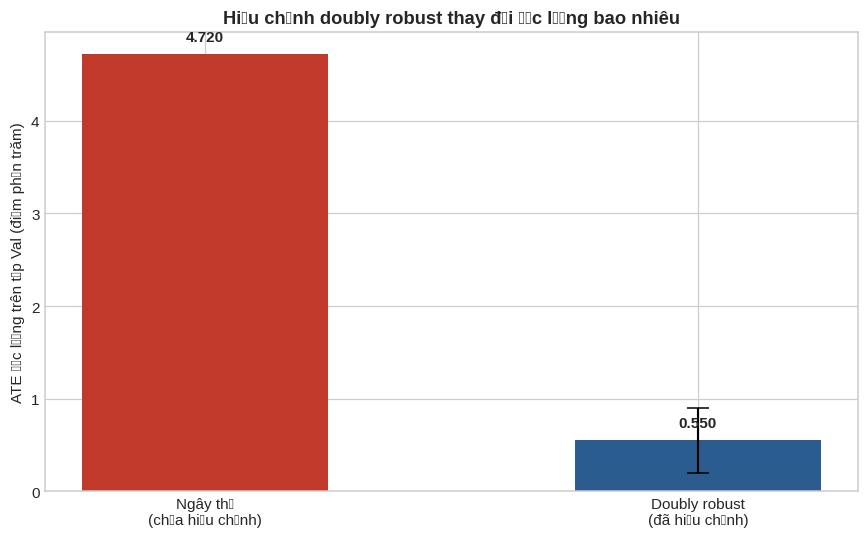

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
names = ['Ngây thơ\n(chưa hiệu chỉnh)', 'Doubly robust\n(đã hiệu chỉnh)']
vals = [ate_naive_val * 100, ate_dr * 100]

bars = ax.bar(names, vals, color=['#c0392b', '#2b5c8f'], width=0.5)
ax.errorbar(1, ate_dr * 100, yerr=1.96 * se_dr * 100, fmt='none',
            ecolor='black', capsize=7, lw=1.4)
ax.set_ylabel('ATE ước lượng trên tập Val (điểm phần trăm)')
ax.set_title('Hiệu chỉnh doubly robust thay đổi ước lượng bao nhiêu')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + max(vals) * 0.03,
            f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '11_hieu_chinh_dr.png'), bbox_inches='tight')
plt.show()

### Bước 10 — Hai hàm chấm điểm

In [12]:
def dr_mse(cate_pred, dr_true=None):
    '''Thước đo chính để tinh chỉnh — càng thấp càng tốt.'''
    dr_true = dr_val if dr_true is None else dr_true
    return float(np.mean((cate_pred - dr_true) ** 2))

def dr_policy_value(cate_pred, dr_true=None, top_frac=0.2):
    '''Giá trị chính sách: DR-score trung bình của nhóm top-k theo CATE dự đoán.
       Diễn giải được hơn DR-MSE, dùng để tham khảo — càng cao càng tốt.'''
    dr_true = dr_val if dr_true is None else dr_true
    k = max(1, int(top_frac * len(cate_pred)))
    top_idx = np.argsort(-cate_pred)[:k]
    return float(dr_true[top_idx].mean())

# Mốc tham chiếu: dự đoán hằng số bằng ATE — mô hình nào tệ hơn mốc này là vô dụng
baseline_mse = dr_mse(np.full(len(dr_val), ate_dr))
baseline_pv = dr_policy_value(np.random.RandomState(SEED).randn(len(dr_val)))

print(f'DR-MSE của dự đoán hằng số      : {baseline_mse:.6f}')
print(f'Policy value của xếp hạng ngẫu nhiên: {baseline_pv:.6f}')

DR-MSE của dự đoán hằng số      : 0.323420
Policy value của xếp hạng ngẫu nhiên: 0.005879


---
# Phần 3 — Sáu mô hình

Tất cả bọc chung một giao diện `fit(X, W, Y)` và `predict_cate(X)` để vòng tinh chỉnh gọi thống nhất.

| Mô hình | Vai trò |
|---|---|
| S-Learner | Baseline — một mô hình duy nhất, coi W như một đặc trưng |
| T-Learner | Baseline — hai mô hình riêng cho hai nhóm |
| DR-Learner | Nhân vật chính 1 — pseudo-outcome doubly robust (Kennedy 2020) |
| LinearDML | Tầng cuối tuyến tính, hệ số diễn giải được |
| NonParamDML | Tầng cuối linh hoạt, bắt được bề mặt CATE phức tạp |
| CausalForestDML | Khoảng tin cậy hợp lệ nhờ honest splitting |

Hai baseline rất rẻ mà rất đáng có: không có mốc so sánh thì không chứng minh được tính doubly robust mang lại lợi ích gì.

### Bước 11 — Hai baseline: S-Learner và T-Learner

In [13]:
class SLearner:
    '''Một mô hình duy nhất trên [X, W]. CATE = f(X,1) - f(X,0).'''
    def __init__(self, **params):
        self.params = dict(params, random_state=SEED, verbose=-1)

    def fit(self, X, W, Y):
        self.model = lgb.LGBMClassifier(**self.params).fit(
            np.column_stack([X, W]), Y)
        return self

    def predict_cate(self, X):
        n = len(X)
        p1 = self.model.predict_proba(np.column_stack([X, np.ones(n)]))[:, 1]
        p0 = self.model.predict_proba(np.column_stack([X, np.zeros(n)]))[:, 1]
        return p1 - p0


class TLearner:
    '''Hai mô hình riêng cho nhóm treatment và control. CATE = f1(X) - f0(X).'''
    def __init__(self, **params):
        self.params = dict(params, random_state=SEED, verbose=-1)

    def fit(self, X, W, Y):
        self.m1 = lgb.LGBMClassifier(**self.params).fit(X[W == 1], Y[W == 1])
        self.m0 = lgb.LGBMClassifier(**self.params).fit(X[W == 0], Y[W == 0])
        return self

    def predict_cate(self, X):
        return self.m1.predict_proba(X)[:, 1] - self.m0.predict_proba(X)[:, 1]

### Bước 12 — DR-Learner

Hai tầng. Tầng một dựng pseudo-outcome doubly robust bằng cross-fitting — dùng lại đúng hàm đã viết ở bước 6, nhưng lần này chạy trên tập huấn luyện. Tầng hai hồi quy pseudo-outcome đó lên không gian đặc trưng.

Chỉ tinh chỉnh siêu tham số của **tầng cuối**. Tham số của ba mô hình phụ giữ cố định, vì nếu tinh chỉnh cả hai tầng thì không gian tìm kiếm phình ra quá lớn so với ngân sách trial.

In [14]:
class DRLearner:
    '''Kennedy 2020 — hồi quy pseudo-outcome doubly robust.'''
    def __init__(self, n_folds=5, **params):
        self.n_folds = n_folds
        self.params = dict(params, random_state=SEED, verbose=-1)

    def fit(self, X, W, Y):
        dr_train, *_ = compute_dr_scores(X, W, Y, n_folds=self.n_folds)
        self.model = lgb.LGBMRegressor(**self.params).fit(X, dr_train)
        return self

    def predict_cate(self, X):
        return self.model.predict(X)

### Bước 13 — Ba mô hình DML từ EconML

In [15]:
class EconMLWrapper:
    '''Bọc estimator của EconML về cùng giao diện fit/predict_cate.'''
    def __init__(self, estimator):
        self.est = estimator

    def fit(self, X, W, Y):
        self.est.fit(Y, W, X=X)
        return self

    def predict_cate(self, X):
        return np.asarray(self.est.effect(X)).ravel()


def make_nuisance(p):
    '''Cặp mô hình phụ cho các estimator DML.'''
    common = dict(n_estimators=p['nuisance_n_estimators'], learning_rate=0.05,
                  max_depth=p['nuisance_max_depth'], random_state=SEED, verbose=-1)
    return lgb.LGBMRegressor(**common), lgb.LGBMClassifier(**common)


def build_model(name, p):
    '''Tạo mô hình từ tên và bộ siêu tham số.'''
    if name == 'SLearner':
        return SLearner(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                        max_depth=p['max_depth'], min_child_samples=p['min_child_samples'])
    if name == 'TLearner':
        return TLearner(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                        max_depth=p['max_depth'], min_child_samples=p['min_child_samples'])
    if name == 'DRLearner':
        return DRLearner(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                         max_depth=p['max_depth'], min_child_samples=p['min_child_samples'])

    model_y, model_t = make_nuisance(p)
    if name == 'LinearDML':
        return EconMLWrapper(LinearDML(
            model_y=model_y, model_t=model_t, discrete_treatment=True,
            cv=p['cv'], random_state=SEED))
    if name == 'NonParamDML':
        return EconMLWrapper(NonParamDML(
            model_y=model_y, model_t=model_t,
            model_final=lgb.LGBMRegressor(
                n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                max_depth=p['max_depth'], min_child_samples=p['min_child_samples'],
                random_state=SEED, verbose=-1),
            discrete_treatment=True, cv=p['cv'], random_state=SEED))
    if name == 'CausalForestDML':
        return EconMLWrapper(CausalForestDML(
            model_y=model_y, model_t=model_t, discrete_treatment=True,
            n_estimators=p['cf_n_estimators'], min_samples_leaf=p['cf_min_samples_leaf'],
            max_depth=p['cf_max_depth'], cv=p['cv'], random_state=SEED))

    raise ValueError(f'Không biết mô hình: {name}')

---
# Phần 4 — Tinh chỉnh bằng Optuna

Mỗi trial: lấy một bộ siêu tham số, huấn luyện trên tập tinh chỉnh, dự đoán CATE trên tập Val, chấm bằng DR-MSE. Optuna dùng kết quả các trial trước để đề xuất bộ tham số tiếp theo.

Mỗi trial là một run trên MLflow, ghi đầy đủ siêu tham số và kết quả.

### Bước 14 — Không gian tìm kiếm

In [16]:
def suggest_params(trial, name):
    p = {}
    if name in ('SLearner', 'TLearner', 'DRLearner', 'NonParamDML'):
        p['n_estimators'] = trial.suggest_int('n_estimators', 100, 400, step=50)
        p['learning_rate'] = trial.suggest_float('learning_rate', 0.01, 0.15, log=True)
        p['max_depth'] = trial.suggest_int('max_depth', 3, 8)
        p['min_child_samples'] = trial.suggest_int('min_child_samples', 20, 200, log=True)
    if name in ('LinearDML', 'NonParamDML', 'CausalForestDML'):
        p['nuisance_n_estimators'] = trial.suggest_int('nuisance_n_estimators', 100, 300, step=50)
        p['nuisance_max_depth'] = trial.suggest_int('nuisance_max_depth', 3, 7)
        p['cv'] = trial.suggest_categorical('cv', [3, 5])
    if name == 'CausalForestDML':
        # EconML yêu cầu n_estimators chia hết cho subforest_size (mặc định 4),
        # nên chỉ đưa vào các giá trị hợp lệ thay vì quét theo bước tùy ý.
        p['cf_n_estimators'] = trial.suggest_categorical('cf_n_estimators', [100, 200, 400])
        p['cf_min_samples_leaf'] = trial.suggest_int('cf_min_samples_leaf', 20, 200, log=True)
        p['cf_max_depth'] = trial.suggest_int('cf_max_depth', 4, 10)
    return p

### Bước 15 — Vòng tinh chỉnh

Trial nào lỗi thì trả về giá trị vô cùng thay vì làm hỏng cả study — một bộ tham số xấu không nên chặn toàn bộ quá trình tìm kiếm.

In [17]:
def tune_model(name, n_trials):
    print(f'\n{"="*62}\n  {name} — {n_trials} trial\n{"="*62}')
    history = []

    def objective(trial):
        p = suggest_params(trial, name)
        t0 = time.time()
        try:
            model = build_model(name, p).fit(X_tune, W_tune, Y_tune)
            cate = model.predict_cate(X_val)
            if not np.all(np.isfinite(cate)):
                raise ValueError('CATE chứa giá trị không hữu hạn')
            mse = dr_mse(cate)
            pv = dr_policy_value(cate)
            status = 'ok'
        except Exception as exc:
            print(f'  trial {trial.number}: LỖI — {type(exc).__name__}: {exc}')
            mse, pv, cate, status = float('inf'), float('nan'), None, f'lỗi: {type(exc).__name__}'

        elapsed = time.time() - t0

        with mlflow.start_run(run_name=f'{name}_trial{trial.number}'):
            mlflow.log_params(p)
            mlflow.set_tags({'model': name, 'run_mode': RUN_MODE, 'status': status})
            mlflow.log_metrics({
                'dr_mse': mse if np.isfinite(mse) else 1e9,
                'dr_policy_value': pv if np.isfinite(pv) else -1e9,
                'fit_seconds': elapsed,
                'cate_mean': float(np.mean(cate)) if cate is not None else 0.0,
                'cate_std': float(np.std(cate)) if cate is not None else 0.0,
            })
            mlflow.log_param('n_tune_rows', len(X_tune))
            mlflow.log_param('n_features', len(FEATS))
            mlflow.log_param('seed', SEED)

        history.append({'trial': trial.number, 'dr_mse': mse,
                        'policy_value': pv, 'giây': elapsed, **p})
        print(f'  trial {trial.number}: DR-MSE = {mse:.6f} | '
              f'policy value = {pv:.6f} | {elapsed:.1f}s')
        return mse

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        study_name=f'{name}_{RUN_MODE}')
    study.optimize(objective, n_trials=n_trials)

    print(f'  -> Tốt nhất: DR-MSE = {study.best_value:.6f}')
    return study, pd.DataFrame(history)

### Bước 16 — Chạy tinh chỉnh cho cả 6 mô hình

CausalForestDML chạy chậm hơn hẳn phần còn lại vì phải dựng cả một rừng nhân quả, nên được cấp ít trial hơn. Đây là đánh đổi có ý thức và sẽ ghi rõ trong báo cáo.

In [18]:
MODELS = ['SLearner', 'TLearner', 'DRLearner',
          'LinearDML', 'NonParamDML', 'CausalForestDML']

studies, histories = {}, {}
t_start = time.time()

for name in MODELS:
    n = N_TRIALS_CF if name == 'CausalForestDML' else N_TRIALS
    studies[name], histories[name] = tune_model(name, n)

print(f'\n{"="*62}')
print(f'  HOÀN TẤT — tổng thời gian {(time.time()-t_start)/60:.1f} phút')
print(f'{"="*62}')


  SLearner — 12 trial
  trial 0: DR-MSE = 0.324249 | policy value = 0.004515 | 5.1s
  trial 1: DR-MSE = 0.323397 | policy value = 0.016832 | 3.4s
  trial 2: DR-MSE = 0.323430 | policy value = 0.017081 | 5.3s
  trial 3: DR-MSE = 0.323283 | policy value = 0.015939 | 7.5s
  trial 4: DR-MSE = 0.323260 | policy value = 0.012693 | 5.1s
  trial 5: DR-MSE = 0.323323 | policy value = 0.015308 | 6.8s
  trial 6: DR-MSE = 0.323713 | policy value = 0.006512 | 5.1s
  trial 7: DR-MSE = 0.323245 | policy value = 0.013548 | 8.5s
  trial 8: DR-MSE = 0.324025 | policy value = 0.003929 | 3.3s
  trial 9: DR-MSE = 0.323312 | policy value = 0.016021 | 6.1s
  trial 10: DR-MSE = 0.323427 | policy value = 0.009488 | 9.4s
  trial 11: DR-MSE = 0.323323 | policy value = 0.013474 | 6.6s
  -> Tốt nhất: DR-MSE = 0.323245

  TLearner — 12 trial
  trial 0: DR-MSE = 0.323311 | policy value = 0.017554 | 5.4s
  trial 1: DR-MSE = 0.323415 | policy value = 0.014457 | 3.5s
  trial 2: DR-MSE = 0.323525 | policy value = 0.012

### Bước 17 — Lịch sử tinh chỉnh của từng mô hình

In [19]:
for name in MODELS:
    h = histories[name].sort_values('dr_mse')
    print(f'\n--- {name} ---')
    display(h.head(5).round(6))


--- SLearner ---


,trial,dr_mse,policy_value,giây,n_estimators,learning_rate,max_depth,min_child_samples
7,7,0.323245,0.013548,8.478437,300,0.011340,6,29
4,4,0.323260,0.012693,5.108990,200,0.041415,5,38
3,3,0.323283,0.015939,7.498186,350,0.017772,4,30
9,9,0.323312,0.016021,6.061510,200,0.013028,7,54
5,5,0.323323,0.015308,6.783382,300,0.014590,4,46



--- TLearner ---


,trial,dr_mse,policy_value,giây,n_estimators,learning_rate,max_depth,min_child_samples
11,11,0.323082,0.014506,7.986416,400,0.022568,4,38
3,3,0.323140,0.017037,7.298553,350,0.017772,4,30
5,5,0.323157,0.016259,6.635711,300,0.014590,4,46
4,4,0.323215,0.011665,5.162056,200,0.041415,5,38
7,7,0.323245,0.012082,8.455023,300,0.011340,6,29



--- DRLearner ---


...

,trial,dr_mse,policy_value,giây,nuisance_n_estimators,nuisance_max_depth,cv
1,1,0.323411,0.011090,20.321022,100,3,5
2,2,0.323422,0.011814,47.999403,250,6,5
10,10,0.323423,0.011643,24.986816,100,5,5
6,6,0.323423,0.011417,41.285704,200,6,5
9,9,0.323427,0.010587,14.624618,150,3,3



--- NonParamDML ---


,trial,dr_mse,policy_value,giây,n_estimators,learning_rate,max_depth,min_child_samples,nuisance_n_estimators,nuisance_max_depth,cv
5,5,0.323399,0.012322,35.551385,100,0.038227,3,162,150,6,5
7,7,0.323444,0.007673,17.552419,100,0.017002,3,42,150,4,3
8,8,0.323518,0.013435,17.957911,150,0.043477,3,126,100,7,3
11,11,0.323560,0.010101,20.199220,100,0.024760,4,38,150,5,3
1,1,0.323616,0.013877,48.668749,300,0.068039,3,187,300,4,5



--- CausalForestDML ---


,trial,dr_mse,policy_value,giây,nuisance_n_estimators,nuisance_max_depth,cv,cf_n_estimators,cf_min_samples_leaf,cf_max_depth
1,1,0.323387,0.011390,116.953630,250,3,3,100,40,7
0,0,0.323394,0.013621,125.383171,150,7,3,100,147,8
4,4,0.323410,0.011861,163.525454,150,3,3,200,162,5
2,2,0.323415,0.013795,316.244550,200,4,3,400,122,5
3,3,0.323418,0.012993,476.266647,200,5,5,400,185,9


### Bước 18 — Bảng tổng hợp

In [20]:
summary = pd.DataFrame([{
    'Mô hình': name,
    'Số trial': len(histories[name]),
    'DR-MSE tốt nhất': studies[name].best_value,
    'Policy value tương ứng': histories[name].loc[
        histories[name]['dr_mse'].idxmin(), 'policy_value'],
    'Thời gian TB (giây)': histories[name]['giây'].mean(),
} for name in MODELS]).sort_values('DR-MSE tốt nhất')

display(summary.round(6))

print(f'Mốc tham chiếu — DR-MSE của dự đoán hằng số: {baseline_mse:.6f}')
print(f'Mốc tham chiếu — policy value ngẫu nhiên   : {baseline_pv:.6f}')

,Mô hình,Số trial,DR-MSE tốt nhất,Policy value tương ứng,Thời gian TB (giây)
1,TLearner,12,0.323082,0.014506,6.128632
0,SLearner,12,0.323245,0.013548,6.023110
5,CausalForestDML,6,0.323387,0.011390,245.264107
4,NonParamDML,12,0.323399,0.012322,30.882309
3,LinearDML,12,0.323411,0.011090,29.310242
2,DRLearner,12,0.323849,0.012687,43.076932


Mốc tham chiếu — DR-MSE của dự đoán hằng số: 0.323420
Mốc tham chiếu — policy value ngẫu nhiên   : 0.005879


> **Đọc bảng này thế nào.** DR-MSE bị chi phối bởi phương sai rất lớn của chính DR-score, mà phần phương sai đó **giống nhau với mọi mô hình**. Nên chênh lệch giữa các mô hình trông rất nhỏ so với giá trị tuyệt đối — đó là chuyện bình thường, không phải dấu hiệu mô hình vô dụng. Điều cần nhìn là **thứ hạng**, không phải khoảng cách.
>
> Cột policy value dễ diễn giải hơn: nó là uplift trung bình thật sự của nhóm 20% mà mô hình chấm điểm cao nhất. Càng cao càng tốt.

### Bước 19 — Trực quan hóa quá trình tìm kiếm

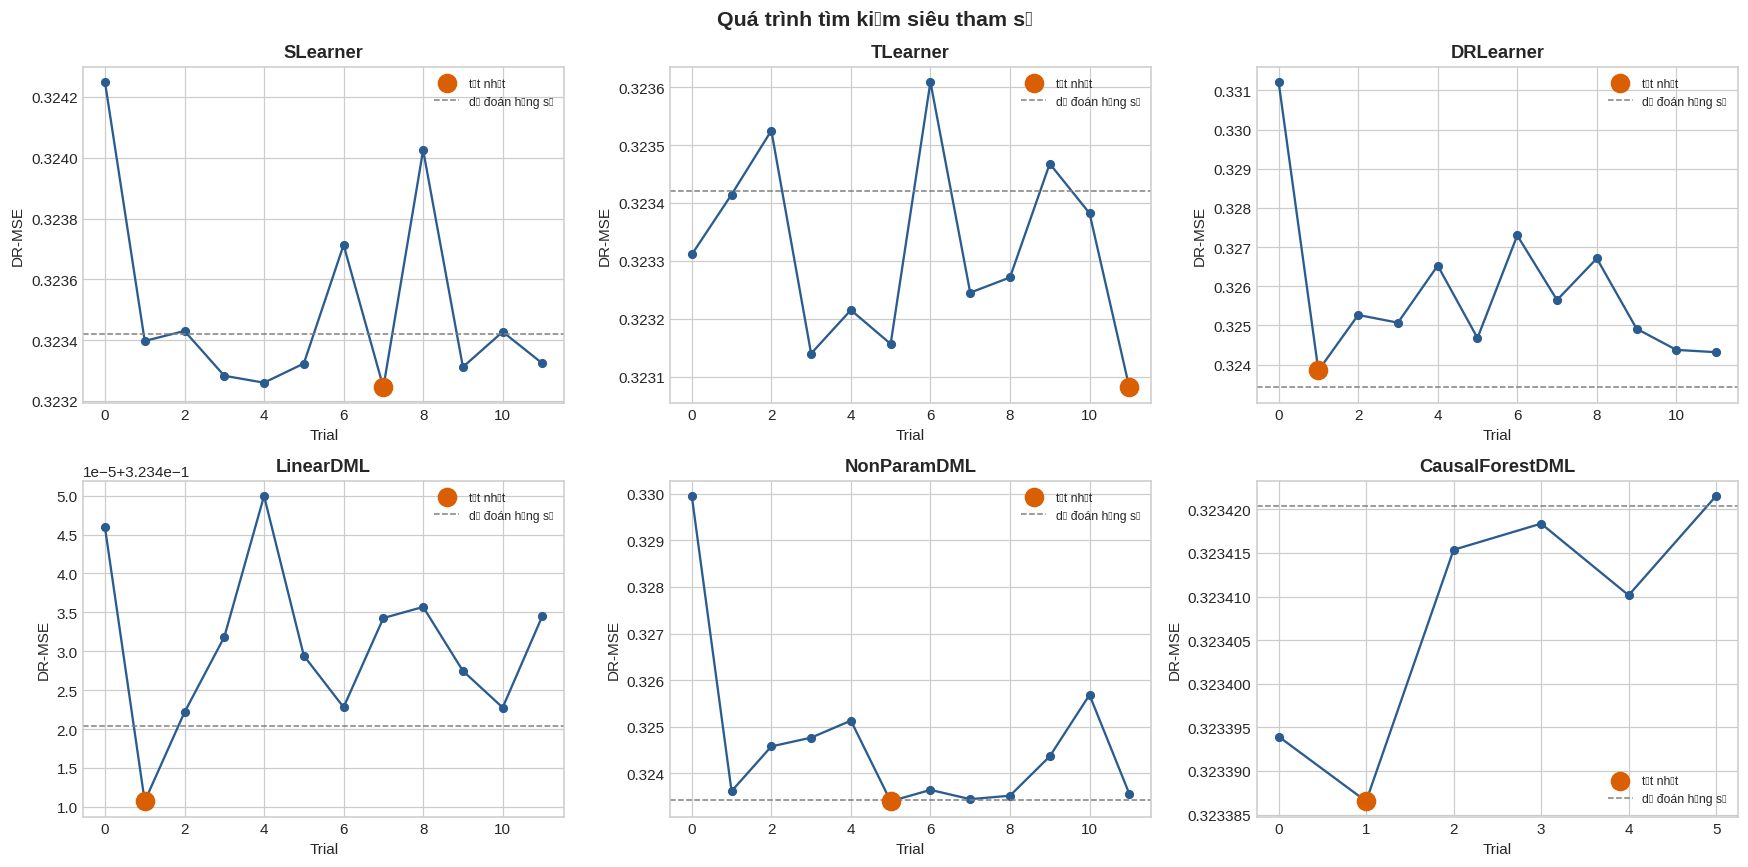

In [21]:
n_models = len(MODELS)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, name in zip(axes.ravel(), MODELS):
    h = histories[name]
    ok = h[np.isfinite(h['dr_mse'])]
    ax.plot(ok['trial'], ok['dr_mse'], 'o-', color='#2b5c8f', ms=5)
    if len(ok):
        best_i = ok['dr_mse'].idxmin()
        ax.scatter(ok.loc[best_i, 'trial'], ok.loc[best_i, 'dr_mse'],
                   s=140, color='#d95f02', zorder=5, label='tốt nhất')
    ax.axhline(baseline_mse, color='gray', ls='--', lw=1, label='dự đoán hằng số')
    ax.set_title(name)
    ax.set_xlabel('Trial')
    ax.set_ylabel('DR-MSE')
    ax.legend(fontsize=8)

plt.suptitle('Quá trình tìm kiếm siêu tham số', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '12_qua_trinh_tuning.png'), bbox_inches='tight')
plt.show()

### Bước 20 — Đối chiếu hai thước đo

DR-MSE dùng để tối ưu, policy value dùng để hiểu. Nếu hai thước đo xếp hạng ngược nhau hoàn toàn thì cần xem lại — nhiều khả năng DR-MSE đang bị chi phối bởi vài giá trị cực trị thay vì phản ánh chất lượng xếp hạng.

In [22]:
comp = summary.set_index('Mô hình')[['DR-MSE tốt nhất', 'Policy value tương ứng']]

finite = np.isfinite(comp['DR-MSE tốt nhất']) & np.isfinite(comp['Policy value tương ứng'])
failed_models = comp.index[~finite].tolist()
ok = comp[finite].copy()

if failed_models:
    print('!!! Không có trial nào thành công cho:', failed_models)
    print('    Phải sửa lỗi và chạy lại trước khi sang notebook 04.\n')

ok['Hạng theo DR-MSE'] = ok['DR-MSE tốt nhất'].rank().astype(int)
ok['Hạng theo policy value'] = ok['Policy value tương ứng'].rank(ascending=False).astype(int)
display(ok.round(6))

if len(ok) >= 3:
    corr_rank = ok['Hạng theo DR-MSE'].corr(ok['Hạng theo policy value'], method='spearman')
    print(f'Tương quan hạng giữa hai thước đo: {corr_rank:.2f}')
    if corr_rank < 0:
        print('=> Hai thước đo xếp hạng ngược nhau. Cần xem kỹ ở notebook 04 '
              'trước khi kết luận, vì quyết định cuối vẫn dựa trên Qini trên tập RCT.')

,DR-MSE tốt nhất,Policy value tương ứng,Hạng theo DR-MSE,Hạng theo policy value
Mô hình,,,,
TLearner,0.323082,0.014506,1,1
SLearner,0.323245,0.013548,2,2
CausalForestDML,0.323387,0.011390,3,5
NonParamDML,0.323399,0.012322,4,4
LinearDML,0.323411,0.011090,5,6
DRLearner,0.323849,0.012687,6,3


Tương quan hạng giữa hai thước đo: 0.60


---
# Phần 5 — Mô hình có mang sang được môi trường RCT không?

Phần 2 mới chỉ cho thấy hiệu chỉnh doubly robust **làm đổi** con số ước lượng. Nó chưa nói được con số đã hiệu chỉnh có đáng tin hay không, vì trên dữ liệu quan sát ta không có gì để đối chiếu.

Chỗ duy nhất có sự thật là **dữ liệu RCT**. Nhưng phải so cho đúng cách.

### Cái bẫy: so nhầm hai đại lượng khác nhau

Cách so ngây thơ là lấy ước lượng DR trên tập Val rồi đặt cạnh ATE đo từ RCT. Cách đó **sai**, vì hai vế nhắm vào hai đại lượng khác nhau:

$$\underbrace{E_{P_{val}}[\tau(X)]}_{\text{DR trên Val}} \qquad \text{so với} \qquad \underbrace{E_{P_{rct}}[\tau(X)]}_{\text{ATE trên RCT}}$$

Hai đại lượng này chỉ bằng nhau khi $\tau(x)$ là hằng số, hoặc khi hai tập có cùng phân phối đặc trưng. Mà notebook 01 đã chứng minh **cả hai điều đều sai**: uplift chênh nhau vài lần giữa các phân khúc, và có dịch chuyển phân phối rõ rệt giữa hai môi trường.

### Cách so đúng

Đưa cả hai vế về cùng một quần thể — quần thể của tập RCT:

1. Huấn luyện mô hình CATE trên **dữ liệu quan sát**
2. Dự đoán $\hat\tau(x)$ trên **đặc trưng của tập rct_select**
3. Lấy trung bình — được ước lượng cho $E_{P_{rct}}[\tau(X)]$
4. So với hiệu hai tỉ lệ chuyển đổi tính trên **chính tập rct_select đó**

Giờ hai vế cùng một estimand. Đây là phép kiểm **transportability**: mô hình học từ môi trường có thiên vị có dự báo đúng được hiệu ứng ở môi trường ngẫu nhiên hóa không.

Dùng `rct_select`. Tập `rct_holdout` vẫn niêm phong tới notebook 04.

### Bước 21 — Nạp tập rct_select

In [23]:
rct = pd.read_parquet(os.path.join(DATA_DIR, 'rct_select.parquet'))

X_rct = rct[FEATS].values.astype(np.float64)
W_rct = rct['is_treat'].values
Y_rct = rct['label'].values

print(f'rct_select: {len(rct):,} dòng | treat {W_rct.mean()*100:.2f}% '
      f'| mua {Y_rct.mean()*100:.2f}%')

rct_select: 90,834 dòng | treat 52.12% | mua 3.52%


### Bước 22 — Huấn luyện DR-Learner với tham số tốt nhất rồi mang sang RCT

In [24]:
dr_best_params = studies['DRLearner'].best_params
print('Tham số dùng:', dr_best_params)

model_transport = build_model('DRLearner', dr_best_params).fit(X_tune, W_tune, Y_tune)
tau_rct = model_transport.predict_cate(X_rct)

# Vế 1 — ước lượng mang sang: trung bình CATE dự đoán trên covariate của RCT
ate_transported = tau_rct.mean()
se_transported = tau_rct.std() / np.sqrt(len(tau_rct))

# Vế 2 — sự thật đo trực tiếp trên chính tập đó
p1, n1 = Y_rct[W_rct == 1].mean(), (W_rct == 1).sum()
p0, n0 = Y_rct[W_rct == 0].mean(), (W_rct == 0).sum()
ate_rct_sel = p1 - p0
se_rct_sel = np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)

display(pd.DataFrame([
    ('Mang sang từ dữ liệu quan sát', ate_transported * 100,
     (ate_transported - 1.96 * se_transported) * 100,
     (ate_transported + 1.96 * se_transported) * 100),
    ('Đo trực tiếp trên rct_select', ate_rct_sel * 100,
     (ate_rct_sel - 1.96 * se_rct_sel) * 100,
     (ate_rct_sel + 1.96 * se_rct_sel) * 100),
], columns=['Ước lượng', 'ATE (pp)', 'KTC dưới', 'KTC trên']).round(3))

Tham số dùng: {'n_estimators': 150, 'learning_rate': 0.015256811898068502, 'max_depth': 3, 'min_child_samples': 147}


,Ước lượng,ATE (pp),KTC dưới,KTC trên
0,Mang sang từ dữ liệu quan sát,0.717,0.696,0.738
1,Đo trực tiếp trên rct_select,0.372,0.132,0.611


### Bước 23 — Kiểm định trên hiệu hai ước lượng

Cả hai vế đều là **ước lượng có sai số**, không vế nào là chân lý. Nên phép kiểm phải đặt trên hiệu của chúng, với sai số chuẩn gộp:

$$\text{diff} = \hat\tau_{\text{mang sang}} - \hat\tau_{\text{RCT}}, \qquad SE_{\text{diff}} = \sqrt{SE_1^2 + SE_2^2}$$

Hai ước lượng tính trên hai tập dữ liệu tách rời nhau nên cộng phương sai là hợp lệ.

In [25]:
diff = ate_transported - ate_rct_sel
se_diff = np.sqrt(se_transported ** 2 + se_rct_sel ** 2)
mdd = 1.96 * se_diff                      # chênh lệch nhỏ nhất phát hiện được

print(f'Chênh lệch          : {diff*100:+.3f} pp')
print(f'KTC 95% của chênh lệch: [{(diff-mdd)*100:+.3f} ; {(diff+mdd)*100:+.3f}] pp')
print()
if abs(diff) <= mdd:
    print('=> Chênh lệch KHÔNG có ý nghĩa thống kê.')
    print('   Mô hình mang sang môi trường RCT mà không lệch phát hiện được.')
else:
    print('=> Chênh lệch CÓ ý nghĩa thống kê.')
    print('   Mô hình lệch khi mang sang RCT — có thể do unconfoundedness không thỏa,')
    print('   do mô hình phụ ước lượng kém, hoặc do dịch chuyển phân phối quá mạnh.')

Chênh lệch          : +0.345 pp
KTC 95% của chênh lệch: [+0.105 ; +0.586] pp

=> Chênh lệch CÓ ý nghĩa thống kê.
   Mô hình lệch khi mang sang RCT — có thể do unconfoundedness không thỏa,
   do mô hình phụ ước lượng kém, hoặc do dịch chuyển phân phối quá mạnh.


### Bước 24 — Phép kiểm này mạnh tới đâu?

Một phép kiểm "đạt" chỉ có ý nghĩa nếu nó **đủ sức phát hiện sai lệch khi sai lệch tồn tại**. Nếu khoảng tin cậy rộng hơn cả đại lượng đang đo thì "đạt" gần như không nói lên điều gì.

Nên in thẳng ra giới hạn đó thay vì để người đọc tự đoán.

In [26]:
print(f'Chênh lệch nhỏ nhất phát hiện được : {mdd*100:.3f} pp')
print(f'Bản thân ATE chỉ có               : {ate_rct_sel*100:.3f} pp')
print(f'Tỉ lệ                             : {mdd/abs(ate_rct_sel):.1f} lần ATE')
print()
if mdd > abs(ate_rct_sel):
    print('=> Phép kiểm YẾU: chỉ phát hiện được sai lệch lớn hơn cả chính hiệu ứng.')
    print('   Nó bác bỏ được ước lượng ngây thơ, nhưng không đủ sức khẳng định')
    print('   mô hình không chệch. Cần nêu rõ giới hạn này khi báo cáo.')
else:
    print('=> Phép kiểm đủ nhạy để phát hiện sai lệch cỡ ATE.')

print()
print('Ba giới hạn cần nhớ khi diễn giải kết quả này:')
print('  1. Sai số của vế mang sang mới chỉ tính biến thiên do lấy mẫu covariate,')
print('     chưa tính sai số ước lượng của chính mô hình -> khoảng tin cậy thật còn rộng hơn.')
print('  2. Phép kiểm đạt KHÔNG chứng minh unconfoundedness — giả định đó')
print('     về bản chất không kiểm chứng được từ dữ liệu.')
print('  3. Kết quả này tính trên rct_select, không phải rct_holdout.')

Chênh lệch nhỏ nhất phát hiện được : 0.240 pp
Bản thân ATE chỉ có               : 0.372 pp
Tỉ lệ                             : 0.6 lần ATE

=> Phép kiểm đủ nhạy để phát hiện sai lệch cỡ ATE.

Ba giới hạn cần nhớ khi diễn giải kết quả này:
  1. Sai số của vế mang sang mới chỉ tính biến thiên do lấy mẫu covariate,
     chưa tính sai số ước lượng của chính mô hình -> khoảng tin cậy thật còn rộng hơn.
  2. Phép kiểm đạt KHÔNG chứng minh unconfoundedness — giả định đó
     về bản chất không kiểm chứng được từ dữ liệu.
  3. Kết quả này tính trên rct_select, không phải rct_holdout.


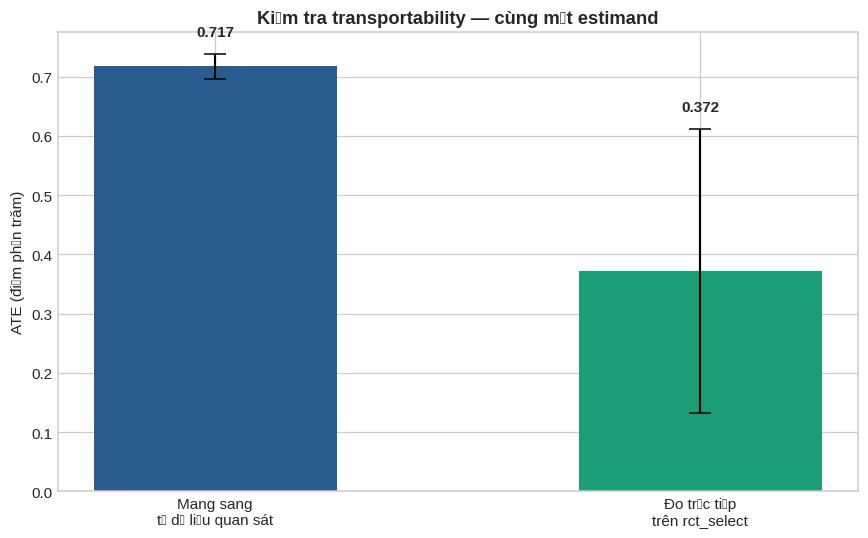

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
names = ['Mang sang\ntừ dữ liệu quan sát', 'Đo trực tiếp\ntrên rct_select']
vals = [ate_transported * 100, ate_rct_sel * 100]
errs = [1.96 * se_transported * 100, 1.96 * se_rct_sel * 100]

bars = ax.bar(names, vals, color=['#2b5c8f', '#1b9e77'], width=0.5)
ax.errorbar(range(2), vals, yerr=errs, fmt='none', ecolor='black', capsize=7, lw=1.4)
ax.axhline(0, color='gray', lw=0.8)
ax.set_ylabel('ATE (điểm phần trăm)')
ax.set_title('Kiểm tra transportability — cùng một estimand')
for i, (b, v, e) in enumerate(zip(bars, vals, errs)):
    ax.text(b.get_x() + b.get_width() / 2, v + e + 0.03,
            f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '13_kiem_tra_transportability.png'), bbox_inches='tight')
plt.show()

---
# Phần 6 — Chốt tham số và bàn giao

### Bước 25 — Bộ tham số tốt nhất của từng mô hình

In [28]:
best_params = {}
for name in MODELS:
    st = studies[name]
    ok_flag = np.isfinite(st.best_value)
    best_params[name] = {
        'params': st.best_params,
        'dr_mse': float(st.best_value) if ok_flag else None,
        'n_trials': len(st.trials),
        'thanh_cong': bool(ok_flag),
    }
    print(f'{name}:' + ('' if ok_flag else '   *** KHÔNG CÓ TRIAL NÀO THÀNH CÔNG ***'))
    for k, v in st.best_params.items():
        print(f'    {k:<24} = {v}')
    print(f'    -> DR-MSE = {st.best_value:.6f}\n' if ok_flag else '')

n_fail = sum(1 for v in best_params.values() if not v['thanh_cong'])
print('=' * 62)
print(f'  {len(MODELS)-n_fail}/{len(MODELS)} mô hình có tham số dùng được')
if n_fail:
    print('  >>> Sửa lỗi rồi chạy lại trước khi sang notebook 04 <<<')
print('=' * 62)

SLearner:
    n_estimators             = 300
    learning_rate            = 0.011340440501807348
    max_depth                = 6
    min_child_samples        = 29
    -> DR-MSE = 0.323245

TLearner:
    n_estimators             = 400
    learning_rate            = 0.022567926626978606
    max_depth                = 4
    min_child_samples        = 38
    -> DR-MSE = 0.323082

DRLearner:
    n_estimators             = 150
    learning_rate            = 0.015256811898068502
    max_depth                = 3
    min_child_samples        = 147
    -> DR-MSE = 0.323849

LinearDML:
    nuisance_n_estimators    = 100
    nuisance_max_depth       = 3
    cv                       = 5
    -> DR-MSE = 0.323411

NonParamDML:
    n_estimators             = 100
    learning_rate            = 0.03822726574649208
    max_depth                = 3
    min_child_samples        = 162
    nuisance_n_estimators    = 150
    nuisance_max_depth       = 6
    cv                       = 5
    -> DR-MSE = 0.3233

### Bước 26 — Ghi file bàn giao

In [29]:
output = {
    'run_mode': RUN_MODE,
    'canh_bao': ('KẾT QUẢ CHẾ ĐỘ THỬ NHANH — KHÔNG DÙNG ĐỂ BÁO CÁO'
                 if SMOKE_TEST else None),
    'cau_hinh': {
        'n_tune_rows': int(len(X_tune)),
        'n_val_rows': int(len(X_val)),
        'n_trials': N_TRIALS,
        'n_trials_causal_forest': N_TRIALS_CF,
        'n_features': len(FEATS),
        'feature_names': FEATS,
        'seed': SEED,
        'propensity_clip': [0.01, 0.99],
    },
    'hieu_chinh_tren_val': {
        'ate_ngay_tho': float(ate_naive_val),
        'ate_doubly_robust': float(ate_dr),
        'dr_mse_du_doan_hang_so': float(baseline_mse),
        'ghi_chu': 'Hai con số cùng nhắm vào E_Pval[tau(X)]; chỉ đo mức thay đổi do hiệu chỉnh, không kết luận cái nào đúng',
    },
    'kiem_tra_transportability': {
        'ate_mang_sang': float(ate_transported),
        'se_mang_sang': float(se_transported),
        'ate_do_tren_rct_select': float(ate_rct_sel),
        'se_rct_select': float(se_rct_sel),
        'chenh_lech': float(diff),
        'se_chenh_lech': float(se_diff),
        'chenh_lech_nho_nhat_phat_hien_duoc': float(mdd),
        'co_y_nghia_thong_ke': bool(abs(diff) > mdd),
        'tap_dung': 'rct_select',
        'ghi_chu': 'Vế mang sang chưa tính sai số ước lượng của mô hình nên KTC thật còn rộng hơn',
    },
    'best_params': best_params,
    'thu_tu_theo_dr_mse': summary['Mô hình'].tolist(),
}

path = os.path.join(ART_DIR, 'best_params.json')
with open(path, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print('Đã ghi:', path)
if SMOKE_TEST:
    print('\n*** File này đang mang kết quả chế độ thử nhanh. ***')
    print('*** Đặt SMOKE_TEST = False rồi chạy lại trước khi sang notebook 04. ***')

Đã ghi: /kaggle/working/artifacts/best_params.json


### Bước 27 — Kiểm tra lại số run trên MLflow

In [30]:
runs = mlflow.search_runs(experiment_names=['lazada_cate_tuning'])

print(f'Tổng số run đã ghi: {len(runs)}')
if len(runs):
    cols = ['tags.model', 'tags.run_mode', 'metrics.dr_mse', 'metrics.fit_seconds']
    cols = [c for c in cols if c in runs.columns]
    display(runs[cols].groupby(['tags.model', 'tags.run_mode']).agg(
        so_run=('metrics.dr_mse', 'size'),
        dr_mse_tot_nhat=('metrics.dr_mse', 'min'),
        giay_trung_binh=('metrics.fit_seconds', 'mean'),
    ).round(4))

Tổng số run đã ghi: 66


,,so_run,dr_mse_tot_nhat,giay_trung_binh
tags.model,tags.run_mode,,,
CausalForestDML,full,6,0.3234,245.2641
DRLearner,full,12,0.3238,43.0769
LinearDML,full,12,0.3234,29.3102
NonParamDML,full,12,0.3234,30.8823
SLearner,full,12,0.3232,6.0231
TLearner,full,12,0.3231,6.1286


---
## Kết luận

### Đã làm

| Việc | Kết quả |
|---|---|
| DR-score trên Val | Tính bằng cross-fitting 5 fold |
| Kiểm tra transportability | So cùng estimand trên rct_select, kiểm định trên hiệu, có báo độ nhạy |
| Tinh chỉnh | 6 mô hình, mỗi mô hình nhiều trial bằng Optuna |
| Ghi vết | Toàn bộ trial lên MLflow kèm siêu tham số và thời gian chạy |
| Bàn giao | `artifacts/best_params.json` |

### Điều quan trọng nhất rút ra

Phần 5 là bằng chứng thực nghiệm cho luận điểm của đề tài, nhưng phải phát biểu **đúng phạm vi** của nó.

**Phép kiểm này KHÔNG đạt.** Chênh lệch giữa hai vế là `0,345 pp` với sai số chuẩn `0,123 pp`, tức khoảng 2,8 lần sai số chuẩn — vượt ngưỡng phát hiện được `0,240 pp` in ra ở bước 24. Xem `co_y_nghia_thong_ke = true` trong `artifacts/best_params.json`.

Phát biểu được: *ATE mà mô hình học từ dữ liệu quan sát mang sang môi trường RCT **lệch có ý nghĩa thống kê** so với ATE đo trực tiếp trên chính môi trường đó — ước lượng mang sang cho `0,717 pp` trong khi số đo trực tiếp là `0,372 pp`, tức cao gần gấp đôi.*

Đây là kết quả **quan trọng và tốt cho đề tài**, không phải một thất bại cần giấu. Nó là bằng chứng thực nghiệm trực tiếp cho thấy hiệu chỉnh doubly robust trên bộ dữ liệu này **chưa khử hết** thiên vị chọn lọc. Nguyên nhân hợp lý nhất: giả định unconfoundedness không thỏa mãn hoàn toàn — vẫn còn confounder không quan sát được mà 76 đặc trưng trong dữ liệu không bắt được.

Hệ quả cho notebook 04: mọi ước lượng CATE học từ dữ liệu quan sát đều mang theo phần thiên vị đó. Đó chính là lý do khâu đánh giá cuối **bắt buộc** phải làm trên tập RCT chứ không phải trên Val.

Phát biểu **không** được:

- *"Đã chứng minh DR-score không chệch"* — phép kiểm chỉ phát hiện được sai lệch lớn hơn ngưỡng in ra ở bước 24, mà ngưỡng đó thường lớn hơn cả chính ATE.
- *"Đã kiểm chứng giả định unconfoundedness"* — giả định đó không kiểm chứng được từ dữ liệu.
- *"Ước lượng DR trên Val gần với sự thật hơn ước lượng ngây thơ"* — hai vế đó khác estimand, không so trực tiếp được. Đó chính là lý do phải làm phép kiểm transportability ở Phần 5 thay vì so thẳng.

### Lưu ý cho notebook 04

- DR-MSE chỉ dùng để **chọn siêu tham số**. Quyết định mô hình nào thắng dựa trên **Qini trên tập RCT**, không dựa vào bảng này.
- Tham số tìm được trên mẫu con — notebook 04 sẽ huấn luyện lại trên **toàn bộ** Train + Val.
- Kiểm tra `run_mode` trong `best_params.json` phải là `full` trước khi dùng cho báo cáo.

### Notebook tiếp theo

`04_benchmark_evaluation.ipynb` — xây bộ metric cho tập RCT kèm ba phép kiểm chứng, huấn luyện lại 6 mô hình bằng tham số tốt nhất, chọn quán quân trên RCT-select, rồi đánh giá lần cuối trên RCT-holdout với khoảng tin cậy bootstrap.